In [41]:
import numpy as np
import random 
import scipy.stats as scist
import matplotlib.pyplot as plt

In [2]:
# function to integrate: y = x**3 * np.exp(-x**2 / 2*sigma**2)
# np.exp(-x**2 / 2*sigma**2) = gaussian * np.sqrt(2*np.pi*sigma**2) 
# p(x) = gaussian
# f(x) = x**3 * np.sqrt(2*np.pi*sigma**2)

In [32]:
def f(x, s):
    y = x**3 * np.sqrt(2*np.pi*s**2)
    return y

In [67]:
def perform_integral(sigma, N):
    #N = number of samplings

    initial_xi = np.random.normal(loc=0, scale=sigma, size=N)
    xi = []

    for i in range(N):
        if initial_xi[i] >=0:
            xi.append(initial_xi[i])

    xi = np.array(xi)
    evaluated = f(xi, sigma)

    integral = 1/len(xi) * np.sum(evaluated) * 1/2
    true_res = 2*sigma**4
    rel_error = (integral-true_res)/true_res

    return integral, rel_error

In [68]:
sigma = 2
N = 20000
results = []
errors = []

for i in range(1000):
    res, err = perform_integral(sigma, N)
    results.append(res)
    errors.append(err)

(array([  2.,   6.,  18.,  44.,  45.,  68., 107., 131., 147., 136., 110.,
         85.,  37.,  36.,  12.,  11.,   1.,   2.,   0.,   2.]),
 array([29.95132629, 30.19421941, 30.43711252, 30.68000564, 30.92289876,
        31.16579187, 31.40868499, 31.65157811, 31.89447122, 32.13736434,
        32.38025745, 32.62315057, 32.86604369, 33.1089368 , 33.35182992,
        33.59472304, 33.83761615, 34.08050927, 34.32340239, 34.5662955 ,
        34.80918862]),
 <BarContainer object of 20 artists>)

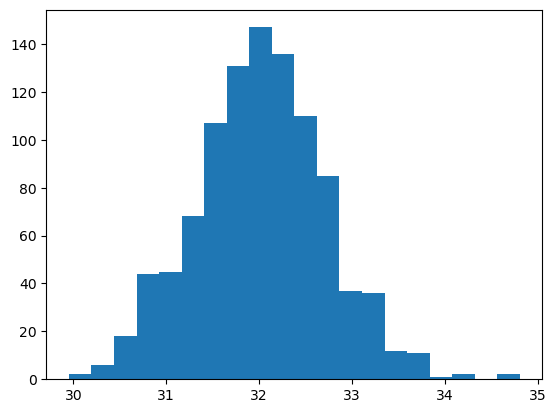

In [69]:
fig, ax = plt.subplots()
plt.hist(results, bins=20)

(array([  2.,   6.,  18.,  44.,  45.,  68., 107., 131., 147., 136., 110.,
         85.,  37.,  36.,  12.,  11.,   1.,   2.,   0.,   2.]),
 array([-0.06402105, -0.05643064, -0.04884023, -0.04124982, -0.03365941,
        -0.026069  , -0.01847859, -0.01088818, -0.00329777,  0.00429264,
         0.01188305,  0.01947346,  0.02706387,  0.03465428,  0.04224468,
         0.04983509,  0.0574255 ,  0.06501591,  0.07260632,  0.08019673,
         0.08778714]),
 <BarContainer object of 20 artists>)

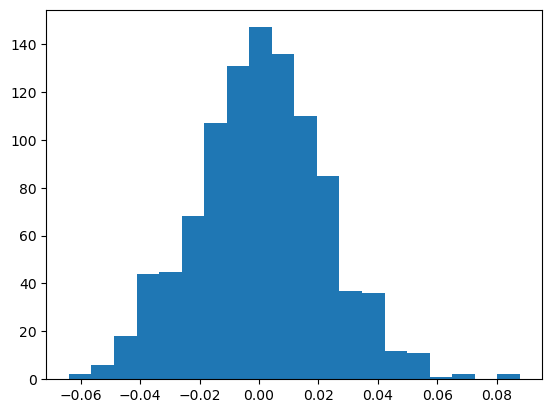

In [70]:
fig, ax = plt.subplots()
plt.hist(errors, bins=20)